# Loan Approval Prediction Using Random Forest

## Project Overview

This project aims to predict whether a loan application should be approved or rejected based on applicant-related and financial attributes using Random Forest algorithm.

### Problem Statement
- **Task**: Binary Classification (Approved/Rejected)
- **Algorithm**: Random Forest Classifier
- **Dataset**: Loan Application Dataset with 20,000 records

### Why Random Forest?
- **Ensemble Learning**: Combines multiple decision trees for better prediction
- **Handles Non-linearity**: Captures complex relationships in data
- **Feature Importance**: Provides insights into which features matter most
- **Robust to Overfitting**: Averaging multiple trees reduces overfitting
- **Handles Missing Values**: Can work with incomplete data

### Project Structure
1. Data Loading and Exploration
2. Data Preprocessing and Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Training (Random Forest)
6. Hyperparameter Tuning
7. Model Evaluation
8. Feature Importance Analysis
9. Results and Insights

---

## 1. Import Required Libraries

In [2]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Machine Learning - Model
from sklearn.ensemble import RandomForestClassifier

# Machine Learning - Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Load and Explore the Dataset

In [3]:
# Load the dataset
df = pd.read_csv('loan_dataset_20000.csv')

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Number of records: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

Dataset loaded successfully!
Dataset shape: (20000, 22)
Number of records: 20000
Number of features: 22


In [4]:
# Display first few rows
print("\n=== First 5 rows of the dataset ===")
df.head()


=== First 5 rows of the dataset ===


,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,loan_purpose,interest_rate,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,Car,13.39,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,Debt consolidation,17.81,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,Business,9.53,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,Other,7.99,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,Car,15.20,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [5]:
# Display dataset information
print("\n=== Dataset Information ===")
df.info()


=== Dataset Information ===
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  str    
 2   marital_status        20000 non-null  str    
 3   education_level       20000 non-null  str    
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  str    
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  str    
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  str    
 15  n

In [6]:
# Statistical summary
print("\n=== Statistical Summary ===")
df.describe()


=== Statistical Summary ===


,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,48.027000,43549.637766,3629.136466,0.177019,679.25695,15129.300909,12.400626,43.22280,455.625794,5.011800,48649.824769,24333.394631,1.990150,0.061800,2.489150,0.799900
std,15.829352,28668.579671,2389.048326,0.105059,69.63858,8605.405513,2.442729,11.00838,274.622125,2.244529,32423.378128,22313.845395,1.474945,0.285105,1.631384,0.400085
min,21.000000,6000.000000,500.000000,0.010000,373.00000,500.000000,3.140000,36.00000,9.430000,0.000000,6157.800000,496.350000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,24260.752500,2021.730000,0.096000,632.00000,8852.695000,10.740000,36.00000,253.910000,3.000000,27180.492500,9592.572500,1.000000,0.000000,1.000000,1.000000
50%,48.000000,36585.260000,3048.770000,0.160000,680.00000,14946.170000,12.400000,36.00000,435.595000,5.000000,40241.615000,18334.555000,2.000000,0.000000,2.000000,1.000000
75%,62.000000,54677.917500,4556.495000,0.241000,727.00000,20998.867500,14.002500,60.00000,633.595000,6.000000,60361.257500,31743.327500,3.000000,0.000000,3.000000,1.000000
max,75.000000,400000.000000,33333.330000,0.667000,850.00000,49039.690000,22.510000,60.00000,1685.400000,15.000000,454394.190000,352177.900000,11.000000,2.000000,11.000000,1.000000


In [8]:
# Target variable distribution
target_col = 'loan_paid_back'
    
print(f"\n=== Target Variable: {target_col} ===")
print(df[target_col].value_counts())
print(f"\nPercentage Distribution:")
print(df[target_col].value_counts(normalize=True) * 100)


=== Target Variable: loan_paid_back ===
loan_paid_back
1    15998
0     4002
Name: count, dtype: int64

Percentage Distribution:
loan_paid_back
1    79.99
0    20.01
Name: proportion, dtype: float64


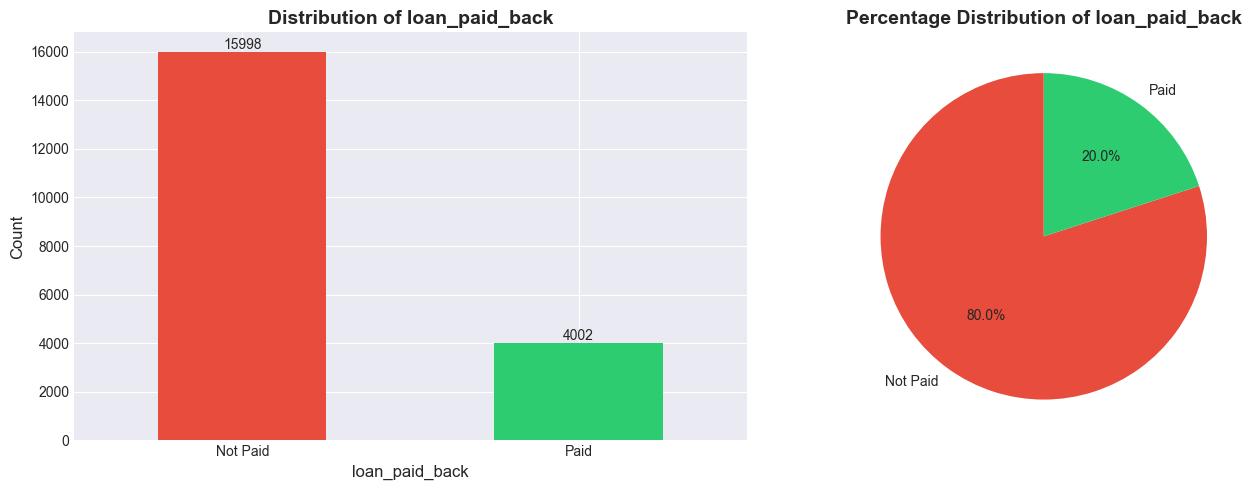

In [9]:
# Visualize target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title(f'Distribution of {target_col}', fontsize=14, fontweight='bold')
axes[0].set_xlabel(target_col, fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['Not Paid', 'Paid'], rotation=0)

# Add value labels on bars
for container in axes[0].containers:
    axes[0].bar_label(container)

# Pie chart
df[target_col].value_counts().plot(
    kind='pie', 
    ax=axes[1], 
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    labels=['Not Paid', 'Paid'],
    startangle=90
)
axes[1].set_title(f'Percentage Distribution of {target_col}', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [10]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")

Categorical columns (6): ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

Numerical columns (16): ['age', 'annual_income', 'monthly_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_term', 'installment', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'public_records', 'num_of_delinquencies', 'loan_paid_back']


## 3. Exploratory Data Analysis (EDA)

In [11]:
# Check for duplicate records
duplicates = df.duplicated().sum()
print(f"\n=== Duplicate Records ===")
print(f"Number of duplicate records: {duplicates}")


=== Duplicate Records ===
Number of duplicate records: 0


In [14]:
# Check for missing values
print("\n=== Missing Values Analysis ===")
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(
    by='Missing Values', ascending=False
)

if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing values found in the dataset!")


=== Missing Values Analysis ===
No missing values found in the dataset!


In [ ]:
# Visualize distribution of numerical features
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols[:9]):
    if col != target_col:
        axes[idx].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Correlation analysis
plt.figure(figsize=(14, 10))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Show correlation with target variable
print("\n=== Correlation with Target Variable ===")
target_corr = df[numerical_cols].corr()[target_col].sort_values(ascending=False)
print(target_corr)

## 4. Data Preprocessing

In [ ]:
# Create a copy of the dataframe for preprocessing
df_processed = df.copy()

print("=== Data Preprocessing Started ===")
print(f"Original dataset shape: {df_processed.shape}")

# Handle categorical variables - Label Encoding
if len(categorical_cols) > 0:
    print("\n=== Encoding Categorical Variables ===")
    label_encoders = {}
    
    for col in categorical_cols:
        if col in df_processed.columns:
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col].astype(str))
            label_encoders[col] = le
            print(f"Encoded: {col}")
    
    print(f"\nTotal categorical columns encoded: {len(label_encoders)}")
else:
    print("\nNo categorical columns to encode")

print("\n✓ Categorical encoding completed!")

In [ ]:
# Separate features and target
X = df_processed.drop(target_col, axis=1)
y = df_processed[target_col]

print("\n=== Feature and Target Separation ===")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}): {list(X.columns)}")